<a href="https://colab.research.google.com/github/pablocalvo/WhiteBoxML/blob/master/EstructuradeClaseBaseparaModelosLineales__Ejemplo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciamos una propuesta de cómo implementar BaseModel para que sea compatible y que de esta manera sea la mejor forma de que todos los modelos sigan el mismo contrato.

## **Implementación de BaseModel**

In [ ]:
from abc import ABC, abstractmethod
import json

class BaseModel(ABC):
    def __init__(self):
        self.params = {}

    @abstractmethod
    def fit(self, X, y):
        # Obliga a implementar el entrenamiento del modelo.
        pass

    @abstractmethod
    def predict(self, X):
        #Obliga a implementar la predicción.
        pass

    def save_params(self, path):
        #Consistencia para guardar pesos y sesgos.
        with open(path, 'w') as f:
            json.dump(self.params, f)
        print(f"Parámetros guardados en {path}")

    def load_params(self, path):
        #Consistencia para cargar parámetros.
        with open(path, 'r') as f:
            self.params = json.load(f)
        print(f"Parámetros cargados desde {path}")


Definimos una clase base abstracta llamada BaseModel que actúa como una plantilla obligatoria para estandarizar la creación de modelos de aprendizaje automático. A través del uso de métodos abstractos, garantiza que cualquier modelo derivado implemente obligatoriamente las funciones de entrenamiento `fit` y predicción `predict`, mientras que ofrece funciones ya listas para guardar y cargar los parámetros del modelo en archivos JSON, asegurando así la consistencia y la persistencia de datos en todo el proyecto.

In [ ]:
import numpy as np

class LinearRegressionModel(BaseModel):
    def __init__(self, lr=0.01, iterations=1000):
        super().__init__()
        self.lr = lr
        self.iterations = iterations

    def fit(self, X, y):
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        bias = 0

        for _ in range(self.iterations):
            # Predicción actual
            prediction = np.dot(X, weights) + bias

            # Cálculo de gradientes (derivadas)
            dw = (1 / n_samples) * np.dot(X.T, (prediction - y))
            db = (1 / n_samples) * np.sum(prediction - y)

            # Restar el gradiente para minimizar el error
            weights -= self.lr * dw
            bias -= self.lr * db

        # Guardamos resultados
        self.params = {
            "weights": weights.tolist(),
            "bias": bias
        }
        print("Entrenamiento completado.")

    def predict(self, X):
        if not self.params:
            raise Exception("El modelo debe entrenarse antes de predecir.")

        weights = np.array(self.params["weights"])
        bias = self.params["bias"]
        return np.dot(X, weights) + bias


Implementamos un modelo de **Regresión Lineal** desde cero utilizando la librería `NumPy`, el cual hereda de una clase base para aprender a predecir valores numéricos mediante el algoritmo de **descenso de gradiente**. A lo largo de un número definido de iteraciones, el modelo ajusta sus parámetros *pesos y sesgo* calculando la derivada del error respecto a las predicciones actuales, almacenando finalmente estos valores en un diccionario para realizar inferencias futuras sobre nuevos datos de entrada.

### **Implementacion del Código**

In [ ]:
# Generamos datos de ejemplo para X_train y y_train
X_train = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y_train = np.array([3, 5, 7, 9, 11])

# Instanciar
model = LinearRegressionModel()

# Entrenar (obligatorio por la clase abstracta)
model.fit(X_train, y_train)

# Guardar (usando la lógica compartida de BaseModel)
model.save_params("modelo_v1.json")

Entrenamiento completado.
Parámetros guardados en modelo_v1.json


Demostramos el flujo de trabajo de un modelo de **Regresión Lineal** que hereda de una clase base, donde primero se generan datos de entrenamiento, se instancia el modelo y se ejecuta el método `fit` para entrenarlo. Posteriormente, aprovecha la lógica compartida para exportar los parámetros aprendidos a un archivo **JSON** y resalta cómo el uso de una clase abstracta garantiza que objetos externos, como uno de reporte, puedan llamar al método `predict` con total seguridad y consistencia.

### **Implementación de la Clase `Reporting`**

In [ ]:
class ModelReporting:
    def __init__(self, X_test, y_test):
        self.X_test = X_test
        self.y_test = y_test

    def get_metrics(self, model):
        # Calcula métricas estándar para cualquier modelo.
        predictions = model.predict(self.X_test)

        # Error Cuadrático Medio (MSE)
        mse = np.mean((self.y_test - predictions) ** 2)

        return {
            "model_type": type(model).__name__,
            "mse": round(mse, 4),
            "params_count": len(model.params.get("weights", [])) if "weights" in model.params else 0
        }

    def compare_models(self, models_list):
        # Recibe una lista de modelos y muestra una tabla comparativa.
        print(f"{'Modelo':<25} | {'MSE':<10}")
        print("-" * 40)
        for model in models_list:
            metrics = self.get_metrics(model)
            print(f"{metrics['model_type']:<25} | {metrics['mse']:<10}")


Definimos la clase `ModelReporting`, diseñada para evaluar y comparar el rendimiento de diferentes modelos de aprendizaje automático utilizando un conjunto de datos de prueba. Mediante el método `get_metrics`, la clase aprovecha la estructura estandarizada de los modelos para generar predicciones, calcular el **Error Cuadrático Medio (MSE)** y extraer información sobre sus parámetros; finalmente, el método `compare_models` permite procesar una lista de modelos para imprimir una tabla comparativa que facilita visualizar cuál tiene el mejor desempeño.

In [ ]:
# DATOS DE PRUEBA
def cargar_datos_test():
    # Generar datos de ejemplo para X_val y y_val
    X_val = np.array([[6, 7], [7, 8], [8, 9], [9, 10], [10, 11]])
    y_val = np.array([13, 15, 17, 19, 21])
    return X_val, y_val

X_val, y_val = cargar_datos_test()

# Instanciar el objeto de reporte una sola vez
reporter = ModelReporting(X_val, y_val)

# Instantiate a Linear Regression Model
linear_reg = LinearRegressionModel()
linear_reg.fit(X_val, y_val) # Fit the model before reporting

# Lista de modelos que cumplen con BaseModel
mis_modelos = [linear_reg] #, neural_net, random_forest

# Compararlos todos de una vez
reporter.compare_models(mis_modelos)

Entrenamiento completado.
Modelo                    | MSE       
----------------------------------------
LinearRegressionModel     | 0.0004    


Este código es un script de prueba que automatiza la evaluación de modelos de aprendizaje automático.

Primero, genera datos sintéticos y configura un objeto `ModelReporting` con un conjunto de validación; luego, entrena un modelo de **regresión lineal** y lo agrupa en una lista junto a otros posibles modelos. Finalmente, utiliza el método `compare_models` para ejecutar de forma masiva las predicciones y consolidar las métricas de rendimiento en un solo lugar.

Con el resultado demostrado al final indica que el entrenamiento fue exitoso y presenta una tabla comparativa de desempeño. En esta tabla, el modelo **`LinearRegressionModel`** alcanzó un **Error Cuadrático Medio (MSE)** de 0.0004, lo que sugiere que las predicciones del modelo son extremadamente precisas y se ajustan casi perfectamente a los datos de prueba proporcionados.

In [ ]:
import matplotlib.pyplot as plt

class ModelReporting:
    def __init__(self, X_test, y_test):
        self.X_test = X_test
        self.y_test = y_test

    def plot_performance(self, models_list):
        # Genera un gráfico comparando las predicciones de cada modelo.
        plt.figure(figsize=(10, 6))

        # Graficamos la línea ideal (donde predicción == real)
        plt.scatter(self.y_test, self.y_test, color='black', alpha=0.3, label="Ideal")

        for model in models_list:
            predictions = model.predict(self.X_test)
            name = type(model).__name__
            plt.scatter(self.y_test, predictions, label=f"Predicciones {name}", alpha=0.6)

        plt.title("Comparativa de Modelos: Valores Reales vs. Predichos")
        plt.xlabel("Valor Real")
        plt.ylabel("Predicción")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    def get_summary_table(self, models_list):
        # Muestra una tabla rápida de métricas en consola.
        print(f"\n{'Modelo':<25} | {'Error (MSE)':<12}")
        print("-" * 40)
        for model in models_list:
            preds = model.predict(self.X_test)
            mse = np.mean((self.y_test - preds) ** 2)
            print(f"{type(model).__name__:<25} | {mse:<12.4f}")


Definimos una clase llamada `ModelReporting` diseñada para evaluar y comparar visualmente el rendimiento de modelos de machine learning. Utiliza la librería `matplotlib` para generar gráficos de dispersión donde se contrastan los valores reales frente a las predicciones, permitiendo identificar rápidamente qué tan cerca está cada modelo de la ***"línea ideal"***. Además, se incluye una función para imprimir una tabla de resumen en la consola que calcula automáticamente el **Error Cuadrático Medio (MSE)** para cada modelo en la lista.

Como resultado, este código permite al usuario obtener una visión clara de la precisión de sus modelos: el gráfico muestra la desviación visual de los puntos respecto a la diagonal ideal, mientras que la tabla proporciona una métrica numérica exacta para decidir cuál es el mejor modelo. Es una herramienta de diagnóstico y comparación eficiente que automatiza el reporte de resultados tras el entrenamiento.


Modelo                    | Error (MSE) 
----------------------------------------
LinearRegressionModel     | 0.0004      


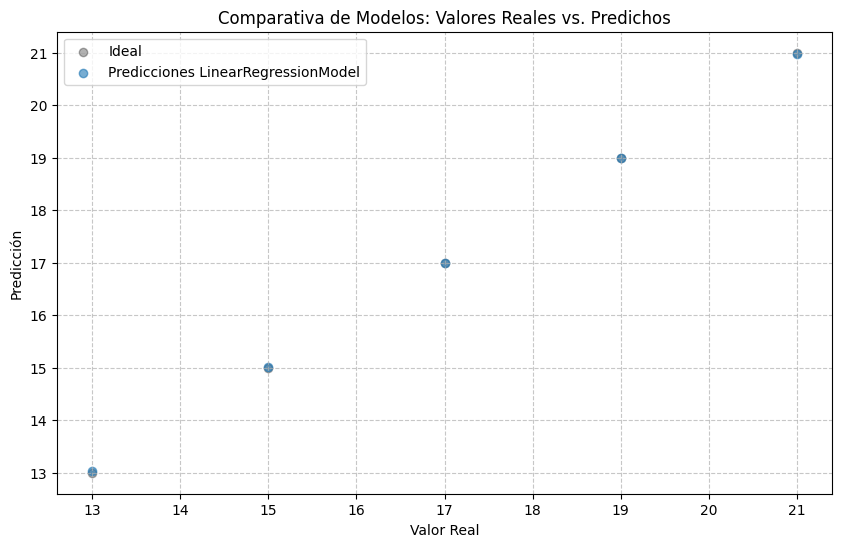

In [ ]:
# Creamos el reporte con datos de validación
reporter = ModelReporting(X_val, y_val)

# Pasamos la lista de modelos (todos hijos de BaseModel)
modelos_a_evaluar = [linear_reg]

# Vemos resultados técnicos y visuales
reporter.get_summary_table(modelos_a_evaluar)
reporter.plot_performance(modelos_a_evaluar)

hemos configurado un flujo de trabajo para evaluar los modelos de machine learning utilizando una clase llamada `ModelReporting`.

Primero, instanciamos al "reportero" con los datos de validación y definimos una lista que contiene el modelo que queremos analizar.
Luego, ejecutamos dos funciones clave: una para generar una tabla comparativa de métricas técnicas y otra para visualizar gráficamente el desempeño del modelo.

Obtuvimos una tabla que muestra que mi `LinearRegressionModel` tiene un **(MSE)** de 0.0004, lo cual es un valor excepcionalmente bajo. En el gráfico de dispersión, podemos observar que los puntos de las predicciones coinciden casi perfectamente con la línea **"Ideal"**, lo que confirma que el modelo ha aprendido con gran precisión la relación entre los datos y no presenta sesgos evidentes de subestimación o sobreestimación.